In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_month'] = pd.to_datetime(df.job_posted_date).dt.strftime("%b")
df = df.dropna(subset=['job_skills'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill))

In [2]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_month
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Jan
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",Oct
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",Jul
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",Aug
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '...",Nov
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete...",Mar
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi...",Mar
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}",Mar
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",Mar


In [3]:
df = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
count = df['job_title_short'].count()
df = df.explode('job_skills')
print(count)

57391


In [6]:
df_altered = df.groupby('job_skills').agg(Count = ('job_skills' , 'count') , Median_Salary = ('salary_year_avg' , 'median'))

df_altered = df_altered.sort_values('Count', ascending = False).head(12)
df_altered
df_altered['Count'] = df_altered['Count'].apply(lambda x: (x/count)*100)
df_altered

,Count,Median_Salary
job_skills,,
sql,60.030318,91000.00
excel,47.950027,84392.00
tableau,33.648133,92875.00
python,32.029412,97500.00
sas,23.000122,90000.00
r,20.315032,92500.00
power bi,20.264501,90000.00
word,13.261661,81194.75
powerpoint,12.501960,85000.00


Text(0, 0.5, 'Median Salary (USD)')

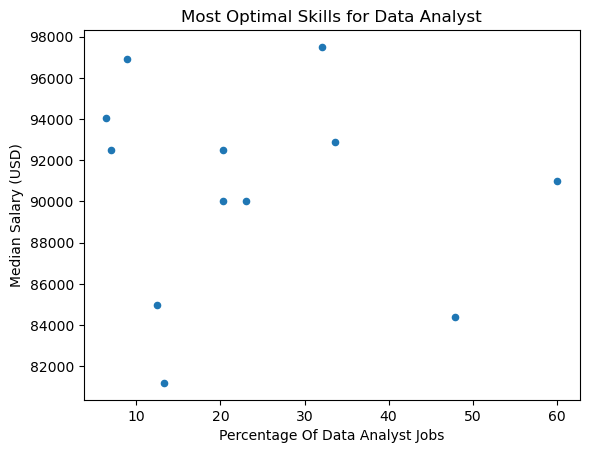

In [8]:
df_altered.plot(kind = 'scatter' , x = 'Count' , y = 'Median_Salary') 
plt.title('Most Optimal Skills for Data Analyst')
plt.xlabel("Percentage Of Data Analyst Jobs")
plt.ylabel("Median Salary (USD)")

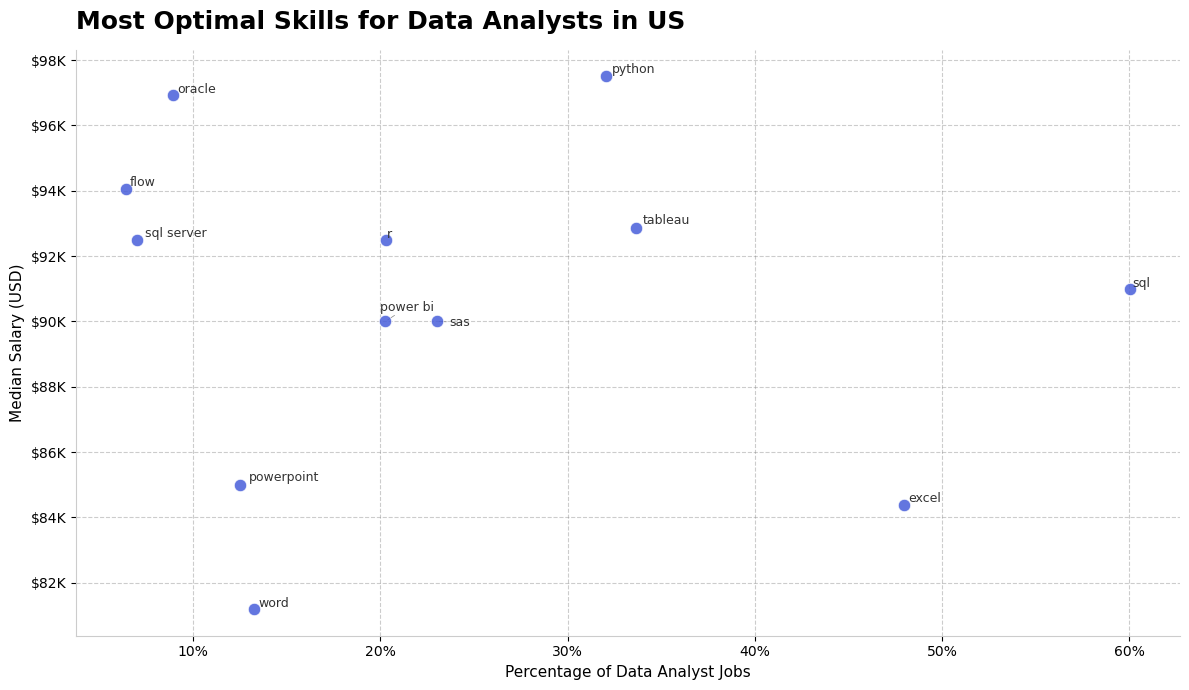

In [16]:
import matplotlib.ticker as mticker
import adjustText

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_altered['Count'],
    df_altered['Median_Salary'],
    color="#485EDA",
    edgecolors='white',
    linewidths=0.6,
    s=80,
    alpha=0.85,
    zorder=3
)

# Labels for each point
texts = []
for _, row in df_altered.iterrows():
    texts.append(ax.text(row['Count'], row['Median_Salary'], row.name, fontsize=9, color='#333333'))

# Auto-adjust labels to avoid overlap
adjustText.adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_title('Most Optimal Skills for Data Analysts in US', fontsize=18, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('Percentage of Data Analyst Jobs', fontsize=11)
ax.set_ylabel('Median Salary (USD)', fontsize=11)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.grid(axis='both', linestyle='--', alpha=0.4, color='gray')
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()